<a href="https://colab.research.google.com/github/geojose911/Python-Basics/blob/main/ecommerce_preprocessed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
data=pd.read_csv('/content/ecommerce_data.csv')

In [ ]:
data.shape

(20000, 27)

In [ ]:
data.dtypes

,0
customer_id,int64
name,object
email,object
country,object
age,int64
age_group,object
signup_date,object
marketing_opt_in,bool
total_orders,int64
total_spend_usd,float64


In [ ]:
data.drop('customer_id', axis=1, inplace=True)


In [ ]:
data.head()

,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,first_order_date,last_order_date,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer
0,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,57.69,7.50,2022-03-18T04:16:29,2025-06-25T16:02:53,paypal,desktop,email,Beauty,3.00,5,desktop,email,2022-03-18T01:58:29,2025-06-25T14:09:53,0,low,1
1,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,34.26,7.50,2023-12-16T17:48:30,2025-01-02T02:48:29,card,desktop,email,Sports,NaN,3,mobile,organic,2021-06-09T11:10:13,2025-01-02T01:01:29,0,low,1
2,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,66.72,15.00,2020-07-04T07:39:11,2020-07-04T07:39:11,wallet,desktop,email,Electronics,NaN,5,mobile,direct,2020-07-04T06:53:11,2025-08-28T11:01:14,0,low,0
3,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,139.93,5.00,2020-09-29T03:07:16,2023-08-01T00:50:26,card,desktop,direct,Beauty,NaN,9,desktop,direct,2020-09-29T02:46:16,2024-11-27T23:38:49,0,medium,1
4,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,90.43,6.67,2024-06-15T21:36:57,2025-01-30T02:03:28,card,desktop,social,Beauty,3.67,9,desktop,organic,2020-01-31T02:47:48,2025-01-29T23:45:28,0,medium,1


In [ ]:
data.drop('name', axis=1, inplace=True)
data.drop('email', axis=1, inplace=True)
data.drop('age', axis=1, inplace=True)


In [ ]:
data.drop('preferred_device_sess', axis=1, inplace=True)
data.drop('preferred_source_sess', axis=1, inplace=True)


In [ ]:
data.drop('first_session_date', axis=1, inplace=True)
data.drop('first_order_date', axis=1, inplace=True)


In [ ]:
data.head()

,country,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,last_order_date,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer
0,JP,55+,2020-09-04,True,2,115.39,57.69,7.50,2025-06-25T16:02:53,paypal,desktop,email,Beauty,3.00,5,2025-06-25T14:09:53,0,low,1
1,IN,25-34,2020-04-05,False,2,68.52,34.26,7.50,2025-01-02T02:48:29,card,desktop,email,Sports,NaN,3,2025-01-02T01:01:29,0,low,1
2,BR,18-24,2023-08-31,True,1,66.72,66.72,15.00,2020-07-04T07:39:11,wallet,desktop,email,Electronics,NaN,5,2025-08-28T11:01:14,0,low,0
3,FR,55+,2022-06-30,True,2,279.86,139.93,5.00,2023-08-01T00:50:26,card,desktop,direct,Beauty,NaN,9,2024-11-27T23:38:49,0,medium,1
4,BR,18-24,2022-07-22,True,3,271.29,90.43,6.67,2025-01-30T02:03:28,card,desktop,social,Beauty,3.67,9,2025-01-29T23:45:28,0,medium,1


In [ ]:
data['signup_date'] = pd.to_datetime(data['signup_date'])
data['last_order_date'] = pd.to_datetime(data['last_order_date'])
data['last_session_date'] = pd.to_datetime(data['last_session_date'])
reference_date = max(data['last_order_date'].max(), data['last_session_date'].max())

print(reference_date)

2025-10-31 23:34:11


In [ ]:
data['customer_age_days']       = (reference_date - data['signup_date']).dt.days
data['days_since_last_order']   = (reference_date - data['last_order_date']).dt.days
data['days_since_last_session'] = (reference_date - data['last_session_date']).dt.days

# drop the raw date columns now that you're done
data.drop(columns=['signup_date', 'last_order_date', 'last_session_date'], inplace=True)

In [ ]:
data.head()

,country,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session
0,JP,55+,True,2,115.39,57.69,7.50,paypal,desktop,email,Beauty,3.00,5,0,low,1,1883,128.0,128.0
1,IN,25-34,False,2,68.52,34.26,7.50,card,desktop,email,Sports,NaN,3,0,low,1,2035,302.0,302.0
2,BR,18-24,True,1,66.72,66.72,15.00,wallet,desktop,email,Electronics,NaN,5,0,low,0,792,1945.0,64.0
3,FR,55+,True,2,279.86,139.93,5.00,card,desktop,direct,Beauty,NaN,9,0,medium,1,1219,822.0,337.0
4,BR,18-24,True,3,271.29,90.43,6.67,card,desktop,social,Beauty,3.67,9,0,medium,1,1197,274.0,274.0


In [ ]:
data['age_group'].unique()

array(['55+', '25-34', '18-24', '45-54', '35-44'], dtype=object)

In [ ]:
data['country'].unique()

array(['JP', 'IN', 'BR', 'FR', 'US', 'GB', 'MX', 'AU', 'SG', 'AE', 'PL',
       'CA', 'DE', 'NL', 'ES', 'SE', 'ZA'], dtype=object)

In [ ]:
print(data['country'].value_counts())
print("Total unique countries:", data['country'].nunique())

country
US    3648
IN    1589
GB    1585
BR    1421
DE    1397
FR    1325
MX    1206
AU    1045
CA    1015
JP     974
ES     950
NL     874
SG     797
SE     621
PL     605
AE     560
ZA     388
Name: count, dtype: int64
Total unique countries: 17


In [ ]:
top_countries = data['country'].value_counts().nlargest(10).index
print(top_countries)


Index(['US', 'IN', 'GB', 'BR', 'DE', 'FR', 'MX', 'AU', 'CA', 'JP'], dtype='object', name='country')


In [ ]:
top_countries = data['country'].value_counts().nlargest(15).index
data['country'] = data['country'].where(data['country'].isin(top_countries), other='Other')

print(data['country'].value_counts())
# should now show only 11 values — top 10 + Other

country
US       3648
IN       1589
GB       1585
BR       1421
DE       1397
FR       1325
MX       1206
AU       1045
CA       1015
JP        974
ES        950
Other     948
NL        874
SG        797
SE        621
PL        605
Name: count, dtype: int64


In [ ]:
# see how many rows each non-top-10 country has
print(data['country'].value_counts().iloc[10:])

country
ES       950
Other    948
NL       874
SG       797
SE       621
PL       605
Name: count, dtype: int64


In [ ]:
data = pd.get_dummies(data, columns=['country'], drop_first=False)


In [ ]:
data.head()

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US
0,55+,True,2,115.39,57.69,7.50,paypal,desktop,email,Beauty,3.00,5,0,low,1,1883,128.0,128.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,25-34,False,2,68.52,34.26,7.50,card,desktop,email,Sports,NaN,3,0,low,1,2035,302.0,302.0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,18-24,True,1,66.72,66.72,15.00,wallet,desktop,email,Electronics,NaN,5,0,low,0,792,1945.0,64.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,55+,True,2,279.86,139.93,5.00,card,desktop,direct,Beauty,NaN,9,0,medium,1,1219,822.0,337.0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,18-24,True,3,271.29,90.43,6.67,card,desktop,social,Beauty,3.67,9,0,medium,1,1197,274.0,274.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
country_cols = [col for col in data.columns if col.startswith('country_')]
data[country_cols] = data[country_cols].astype(int)

In [ ]:
data.head()

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US
0,55+,True,2,115.39,57.69,7.50,paypal,desktop,email,Beauty,3.00,5,0,low,1,1883,128.0,128.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,25-34,False,2,68.52,34.26,7.50,card,desktop,email,Sports,NaN,3,0,low,1,2035,302.0,302.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,18-24,True,1,66.72,66.72,15.00,wallet,desktop,email,Electronics,NaN,5,0,low,0,792,1945.0,64.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,55+,True,2,279.86,139.93,5.00,card,desktop,direct,Beauty,NaN,9,0,medium,1,1219,822.0,337.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,18-24,True,3,271.29,90.43,6.67,card,desktop,social,Beauty,3.67,9,0,medium,1,1197,274.0,274.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# check a specific row's country columns
print(data[[col for col in data.columns if col.startswith('country_')]].head(10))


   country_AU  country_BR  country_CA  country_DE  country_ES  country_FR  \
0           0           0           0           0           0           0   
1           0           0           0           0           0           0   
2           0           1           0           0           0           0   
3           0           0           0           0           0           1   
4           0           1           0           0           0           0   
5           0           0           0           0           0           0   
6           0           0           0           0           0           0   
7           0           0           0           0           0           0   
8           0           0           0           0           0           0   
9           0           0           0           0           0           0   

   country_GB  country_IN  country_JP  country_MX  country_NL  country_Other  \
0           0           0           1           0           0           

In [ ]:
pd.set_option('display.max_columns', None)
data.head()

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US
0,55+,True,2,115.39,57.69,7.50,paypal,desktop,email,Beauty,3.00,5,0,low,1,1883,128.0,128.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,25-34,False,2,68.52,34.26,7.50,card,desktop,email,Sports,NaN,3,0,low,1,2035,302.0,302.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,18-24,True,1,66.72,66.72,15.00,wallet,desktop,email,Electronics,NaN,5,0,low,0,792,1945.0,64.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,55+,True,2,279.86,139.93,5.00,card,desktop,direct,Beauty,NaN,9,0,medium,1,1219,822.0,337.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,18-24,True,3,271.29,90.43,6.67,card,desktop,social,Beauty,3.67,9,0,medium,1,1197,274.0,274.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
age_order = {'18-24': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55+': 4}
data['age_group'] = data['age_group'].map(age_order)

print(data['age_group'].value_counts())

age_group
4    7243
1    3498
3    3445
2    3400
0    2414
Name: count, dtype: int64


In [ ]:
data.head()

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US
0,4,True,2,115.39,57.69,7.50,paypal,desktop,email,Beauty,3.00,5,0,low,1,1883,128.0,128.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,1,False,2,68.52,34.26,7.50,card,desktop,email,Sports,NaN,3,0,low,1,2035,302.0,302.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,True,1,66.72,66.72,15.00,wallet,desktop,email,Electronics,NaN,5,0,low,0,792,1945.0,64.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,True,2,279.86,139.93,5.00,card,desktop,direct,Beauty,NaN,9,0,medium,1,1219,822.0,337.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,True,3,271.29,90.43,6.67,card,desktop,social,Beauty,3.67,9,0,medium,1,1197,274.0,274.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
data['marketing_opt_in'] = data['marketing_opt_in'].map({True: 1, False: 0})

In [ ]:
data.head()

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,preferred_payment,preferred_device_ord,preferred_source,top_category_bought,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US
0,4,1,2,115.39,57.69,7.50,paypal,desktop,email,Beauty,3.00,5,0,low,1,1883,128.0,128.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,1,0,2,68.52,34.26,7.50,card,desktop,email,Sports,NaN,3,0,low,1,2035,302.0,302.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,1,1,66.72,66.72,15.00,wallet,desktop,email,Electronics,NaN,5,0,low,0,792,1945.0,64.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,1,2,279.86,139.93,5.00,card,desktop,direct,Beauty,NaN,9,0,medium,1,1219,822.0,337.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,1,3,271.29,90.43,6.67,card,desktop,social,Beauty,3.67,9,0,medium,1,1197,274.0,274.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(data['preferred_payment'].value_counts())
print(data['preferred_device_ord'].value_counts())
print(data['preferred_source'].value_counts())
print(data['top_category_bought'].value_counts())

preferred_payment
card      13522
paypal     1451
wallet      799
cod         496
Name: count, dtype: int64
preferred_device_ord
mobile     8050
desktop    7720
tablet      498
Name: count, dtype: int64
preferred_source
direct      6013
organic     5465
email       1666
paid        1335
social      1038
referral     751
Name: count, dtype: int64
top_category_bought
Beauty            4306
Books             3459
Fashion           2290
Home & Kitchen    1834
Toys              1673
Sports            1392
Electronics       1314
Name: count, dtype: int64


In [ ]:
data = pd.get_dummies(data, columns=['preferred_payment'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['preferred_device_ord'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['preferred_source'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['top_category_bought'], drop_first=False, dtype=int)


In [ ]:
data.head()

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US,preferred_payment_card,preferred_payment_cod,preferred_payment_paypal,preferred_payment_wallet,preferred_device_ord_desktop,preferred_device_ord_mobile,preferred_device_ord_tablet,preferred_source_direct,preferred_source_email,preferred_source_organic,preferred_source_paid,preferred_source_referral,preferred_source_social,top_category_bought_Beauty,top_category_bought_Books,top_category_bought_Electronics,top_category_bought_Fashion,top_category_bought_Home & Kitchen,top_category_bought_Sports,top_category_bought_Toys
0,4,1,2,115.39,57.69,7.50,3.00,5,0,low,1,1883,128.0,128.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,1,0,2,68.52,34.26,7.50,NaN,3,0,low,1,2035,302.0,302.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2,0,1,1,66.72,66.72,15.00,NaN,5,0,low,0,792,1945.0,64.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,4,1,2,279.86,139.93,5.00,NaN,9,0,medium,1,1219,822.0,337.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
4,0,1,3,271.29,90.43,6.67,3.67,9,0,medium,1,1197,274.0,274.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0


In [ ]:
data.shape

(20000, 50)

In [ ]:
data.isna().sum()

,0
age_group,0
marketing_opt_in,0
total_orders,0
total_spend_usd,0
avg_order_value,0
avg_discount_pct,0
avg_rating_given,14741
total_sessions,0
has_abandoned_cart,0
clv_tier,0


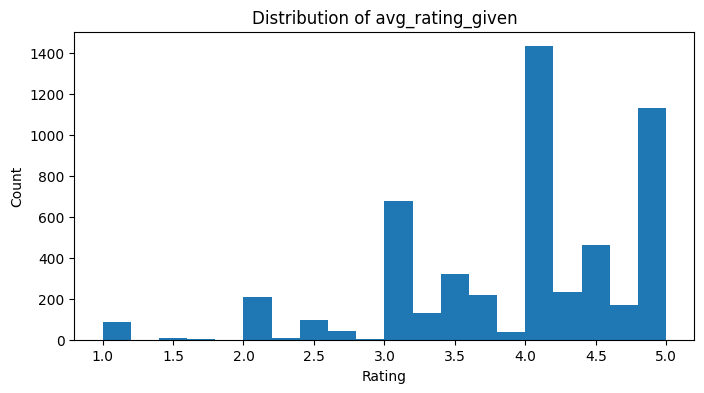

In [ ]:

plt.figure(figsize=(8, 4))
plt.hist(data['avg_rating_given'].dropna(), bins=20)
plt.title('Distribution of avg_rating_given')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:
print('Total nulls : ', data['avg_rating_given'].isna().sum())
median_rating = data['avg_rating_given'].median()
data['avg_rating_given'] = data['avg_rating_given'].fillna(median_rating)

print("Median used:", median_rating)
print("Nulls remaining:", data['avg_rating_given'].isna().sum())  # should be 0

Total nulls :  14741
Median used: 4.0
Nulls remaining: 0


In [ ]:
data.head(15)

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US,preferred_payment_card,preferred_payment_cod,preferred_payment_paypal,preferred_payment_wallet,preferred_device_ord_desktop,preferred_device_ord_mobile,preferred_device_ord_tablet,preferred_source_direct,preferred_source_email,preferred_source_organic,preferred_source_paid,preferred_source_referral,preferred_source_social,top_category_bought_Beauty,top_category_bought_Books,top_category_bought_Electronics,top_category_bought_Fashion,top_category_bought_Home & Kitchen,top_category_bought_Sports,top_category_bought_Toys
0,4,1,2,115.39,57.69,7.50,3.00,5,0,low,1,1883,128.0,128.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,1,0,2,68.52,34.26,7.50,4.00,3,0,low,1,2035,302.0,302.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2,0,1,1,66.72,66.72,15.00,4.00,5,0,low,0,792,1945.0,64.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,4,1,2,279.86,139.93,5.00,4.00,9,0,medium,1,1219,822.0,337.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
4,0,1,3,271.29,90.43,6.67,3.67,9,0,medium,1,1197,274.0,274.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
5,1,0,4,387.40,96.85,5.00,4.25,7,0,medium,1,1836,338.0,234.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
6,3,0,2,96.81,48.40,5.00,4.00,7,0,low,1,99,1146.0,112.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
7,1,1,1,207.40,207.40,5.00,4.00,5,0,medium,0,1118,1910.0,842.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0
8,1,1,1,122.51,122.51,0.00,4.00,4,0,low,0,459,528.0,75.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
9,2,1,3,398.85,132.95,1.67,3.67,6,0,medium,1,1022,943.0,286.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0


In [ ]:
max_days = data['days_since_last_order'].max()
data['days_since_last_order'] = data['days_since_last_order'].fillna(max_days)

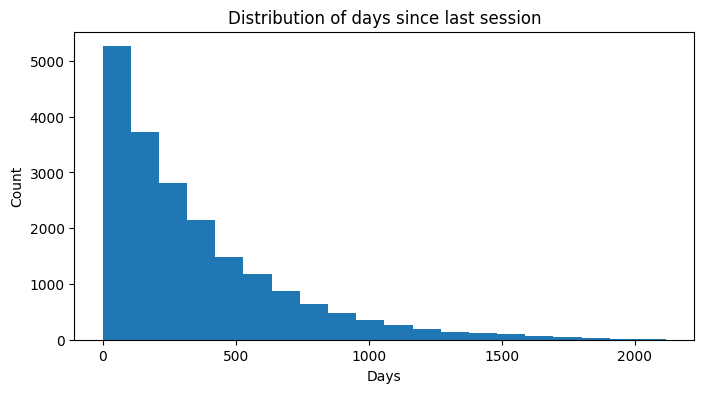

In [ ]:

plt.figure(figsize=(8, 4))
plt.hist(data['days_since_last_session'].dropna(), bins=20)
plt.title('Distribution of days since last session')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

In [ ]:
data['days_since_last_session'] = data['days_since_last_session'].fillna(data['days_since_last_session'].median())

In [ ]:
data.isna().sum()

,0
age_group,0
marketing_opt_in,0
total_orders,0
total_spend_usd,0
avg_order_value,0
avg_discount_pct,0
avg_rating_given,0
total_sessions,0
has_abandoned_cart,0
clv_tier,0


In [ ]:
data.head()

,age_group,marketing_opt_in,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,avg_rating_given,total_sessions,has_abandoned_cart,clv_tier,is_repeat_customer,customer_age_days,days_since_last_order,days_since_last_session,country_AU,country_BR,country_CA,country_DE,country_ES,country_FR,country_GB,country_IN,country_JP,country_MX,country_NL,country_Other,country_PL,country_SE,country_SG,country_US,preferred_payment_card,preferred_payment_cod,preferred_payment_paypal,preferred_payment_wallet,preferred_device_ord_desktop,preferred_device_ord_mobile,preferred_device_ord_tablet,preferred_source_direct,preferred_source_email,preferred_source_organic,preferred_source_paid,preferred_source_referral,preferred_source_social,top_category_bought_Beauty,top_category_bought_Books,top_category_bought_Electronics,top_category_bought_Fashion,top_category_bought_Home & Kitchen,top_category_bought_Sports,top_category_bought_Toys
0,4,1,2,115.39,57.69,7.50,3.00,5,0,low,1,1883,128.0,128.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,1,0,2,68.52,34.26,7.50,4.00,3,0,low,1,2035,302.0,302.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2,0,1,1,66.72,66.72,15.00,4.00,5,0,low,0,792,1945.0,64.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,4,1,2,279.86,139.93,5.00,4.00,9,0,medium,1,1219,822.0,337.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
4,0,1,3,271.29,90.43,6.67,3.67,9,0,medium,1,1197,274.0,274.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0


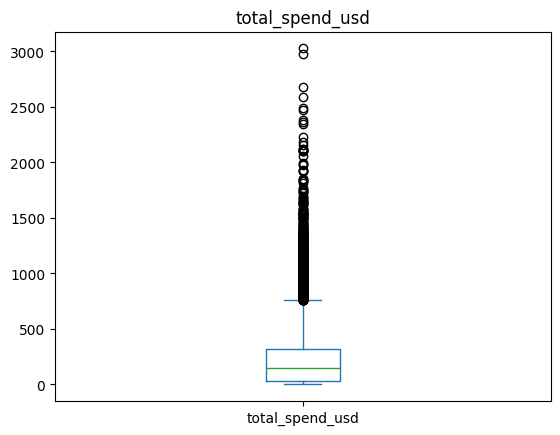

In [ ]:

data['total_spend_usd'].dropna().plot(kind='box')
plt.title('total_spend_usd')
plt.show()


In [ ]:
Q1 = data['total_spend_usd'].quantile(0.25)
Q3 = data['total_spend_usd'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper limit: {upper_limit}")
print(f"Outliers: {(data['total_spend_usd'] > upper_limit).sum()}")

# cap outliers at upper limit
data['total_spend_usd'] = data['total_spend_usd'].clip(upper=upper_limit)

Q1: 32.160000000000004, Q3: 322.4, IQR: 290.23999999999995
Upper limit: 757.7599999999999
Outliers: 914


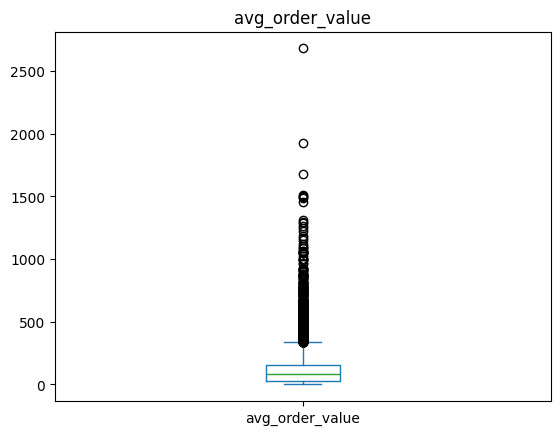

In [ ]:

data['avg_order_value'].dropna().plot(kind='box')
plt.title('avg_order_value')
plt.show()

In [ ]:
Q1 = data['avg_order_value'].quantile(0.25)
Q3 = data['avg_order_value'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper limit: {upper_limit}")
print(f"Outliers: {(data['avg_order_value'] > upper_limit).sum()}")

# cap outliers at upper limit
data['avg_order_value'] = data['avg_order_value'].clip(upper=upper_limit)

Q1: 27.14, Q3: 151.0525, IQR: 123.91250000000001
Upper limit: 336.92125
Outliers: 851


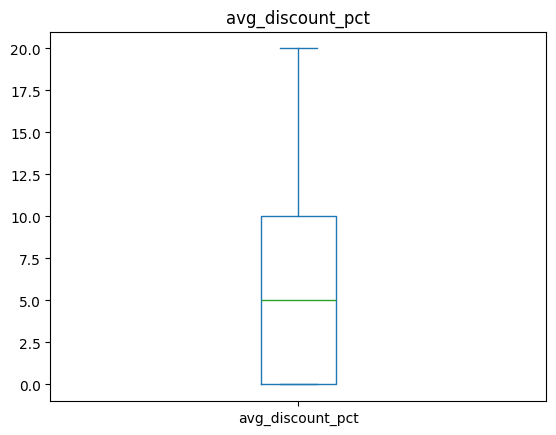

In [ ]:
data['avg_discount_pct'].dropna().plot(kind='box')
plt.title('avg_discount_pct')
plt.show()

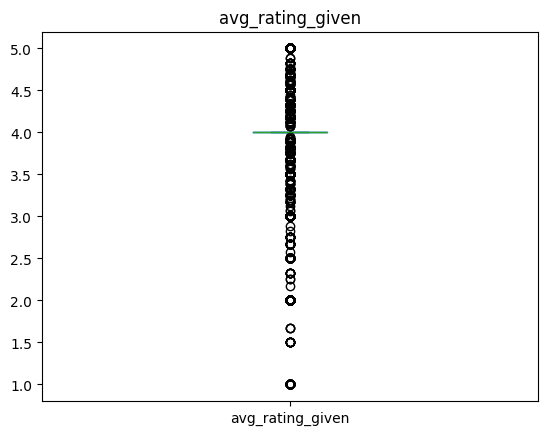

In [ ]:
data['avg_rating_given'].dropna().plot(kind='box')
plt.title('avg_rating_given')
plt.show()

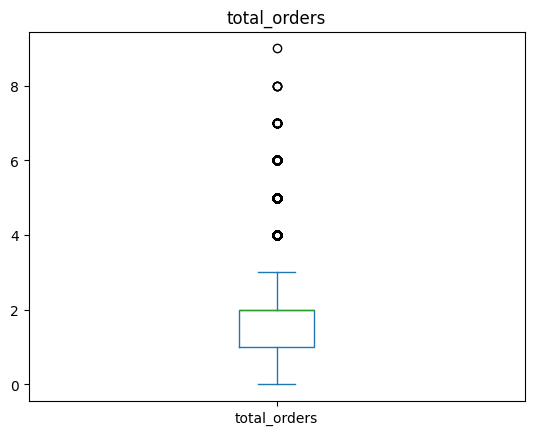

In [ ]:
data['total_orders'].dropna().plot(kind='box')
plt.title('total_orders')
plt.show()


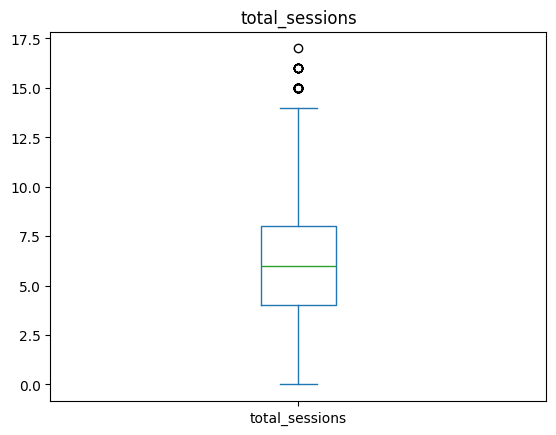

In [ ]:

data['total_sessions'].dropna().plot(kind='box')
plt.title('total_sessions')
plt.show()

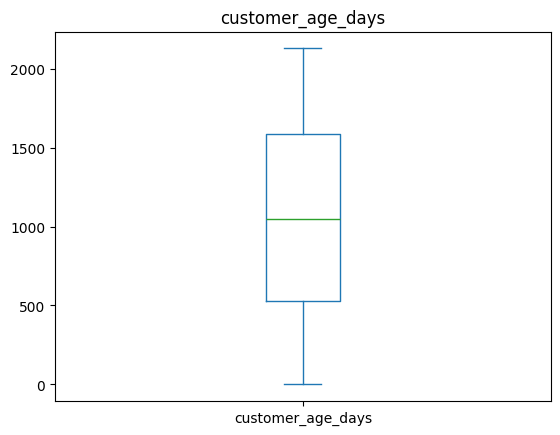

In [ ]:
data['customer_age_days'].dropna().plot(kind='box')
plt.title('customer_age_days')
plt.show()

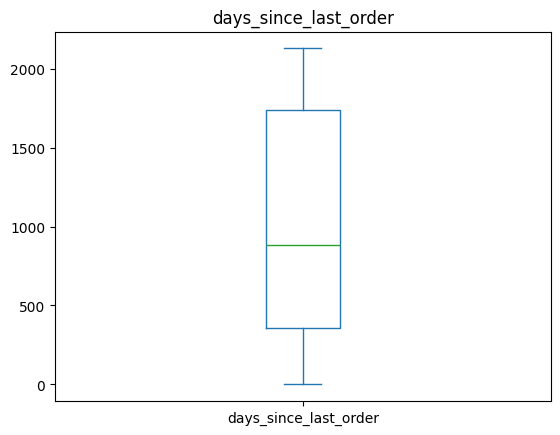

In [ ]:
data['days_since_last_order'].dropna().plot(kind='box')
plt.title('days_since_last_order')
plt.show()


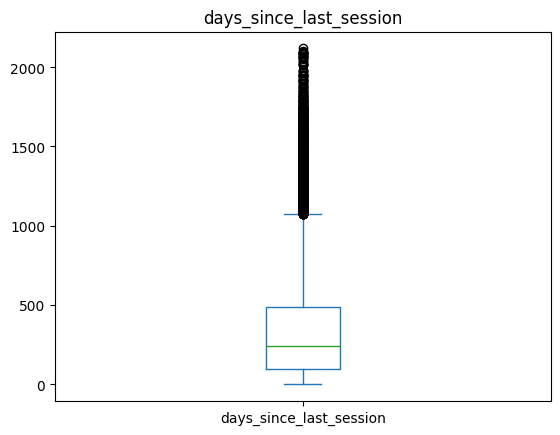

In [ ]:
data['days_since_last_session'].dropna().plot(kind='box')
plt.title('days_since_last_session')
plt.show()

In [ ]:
Q1 = data['days_since_last_session'].quantile(0.25)
Q3 = data['days_since_last_session'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper limit: {upper_limit}")
print(f"Outliers: {(data['days_since_last_session'] > upper_limit).sum()}")

# cap outliers at upper limit
data['days_since_last_session'] = data['days_since_last_session'].clip(upper=upper_limit)

Q1: 99.0, Q3: 489.0, IQR: 390.0
Upper limit: 1074.0
Outliers: 944
